# Drift correction - Cedric dataset_1 (1024x1024, 49 tilts)

Samsung GAAFET tilt series. Paired 0 deg and 90 deg scans at each tilt angle.

- Shape: (49, 1024, 1024) uint16
- Tilt range: 0 to +46 deg, 0 to -60 deg

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import time
import quantem as em

/home/owner/miniforge3/envs/cuda-env/lib/python3.13/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [3]:
DATA_DIR = "/home/owner/data/cedric/drift/20260207_samsung_GAAFET/dataset_1"

images_0deg  = np.load(f"{DATA_DIR}/0_deg_images.npy")
images_90deg = np.load(f"{DATA_DIR}/90_deg_images.npy")
tilt_angles  = np.load(f"{DATA_DIR}/tilt_angles.npy")
n_tilts = images_0deg.shape[0]

print(f"0-deg:  shape={images_0deg.shape}, dtype={images_0deg.dtype}")
print(f"90-deg: shape={images_90deg.shape}, dtype={images_90deg.dtype}")
print(f"tilts:  {tilt_angles[:n_tilts]}")

0-deg:  shape=(49, 1024, 1024), dtype=uint16
90-deg: shape=(49, 1024, 1024), dtype=uint16
tilts:  [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46   0  -2  -4  -6  -8 -10 -12 -14 -16 -18 -20 -22
 -24 -26 -28 -30 -32 -34 -36 -38 -40 -42 -44 -46 -48]


## Preview: raw 0 deg vs 90 deg at tilt 0

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'tilt=0: 0 deg'}>,
        <Axes: title={'center': 'tilt=0: 90 deg (rotated back)'}>,
        <Axes: title={'center': '|difference| (mean=443)'}>], dtype=object))

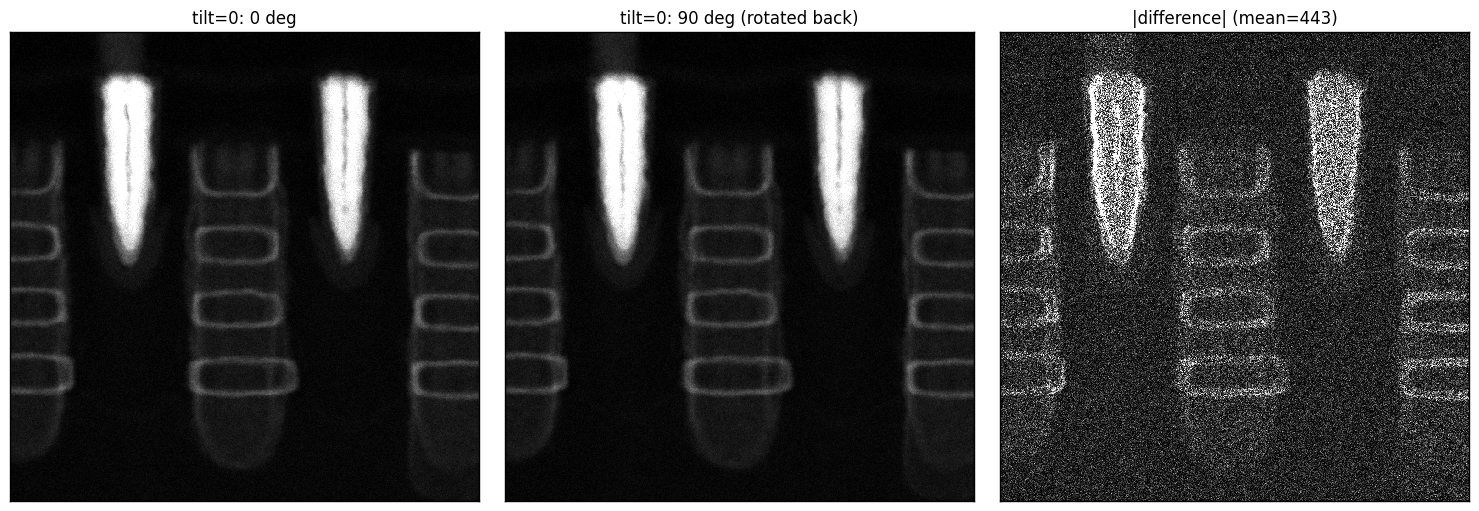

In [4]:
im90_rot = np.rot90(images_90deg[0], k=-1)
diff = np.abs(images_0deg[0].astype(float) - im90_rot.astype(float))
em.visualization.show_2d(
    [images_0deg[0], im90_rot, diff],
    cmap="gray",
    axsize=(5, 5),
    title=[
        f"tilt={tilt_angles[0]}: 0 deg",
        f"tilt={tilt_angles[0]}: 90 deg (rotated back)",
        f"|difference| (mean={diff.mean():.0f})",
    ],
)

## Drift correction over all tilt angles

In [ ]:
import time
t0 = time.perf_counter()

corrected_stack, drift_objects = em.imaging.correct_series(
    images_0deg, images_90deg,
    scan_direction_degrees=[0, -90],
    preprocess=dict(pad_fraction=0.25, pad_value="median", kde_sigma=0.5, number_knots=1),
    align_affine=dict(step=0.02, num_tests=11),
    generate=dict(upsample_factor=1, kde_sigma=0.5),
)

print(f"Total: {time.perf_counter() - t0:.1f}s  ({n_tilts} tilts)")

## Before vs After: tilt 0, middle, last

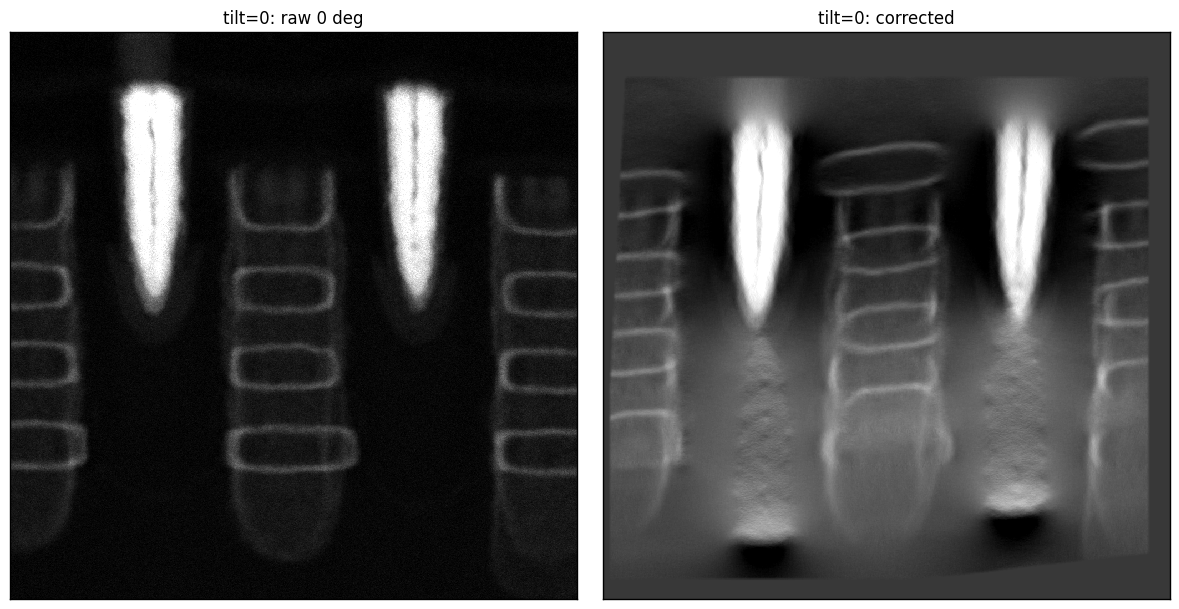

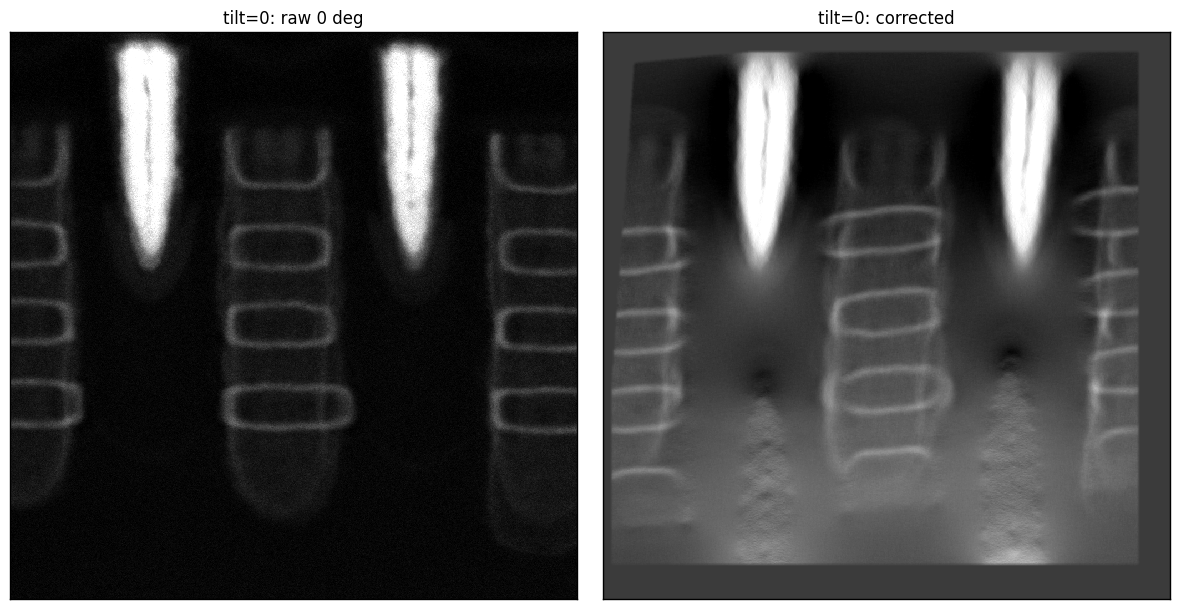

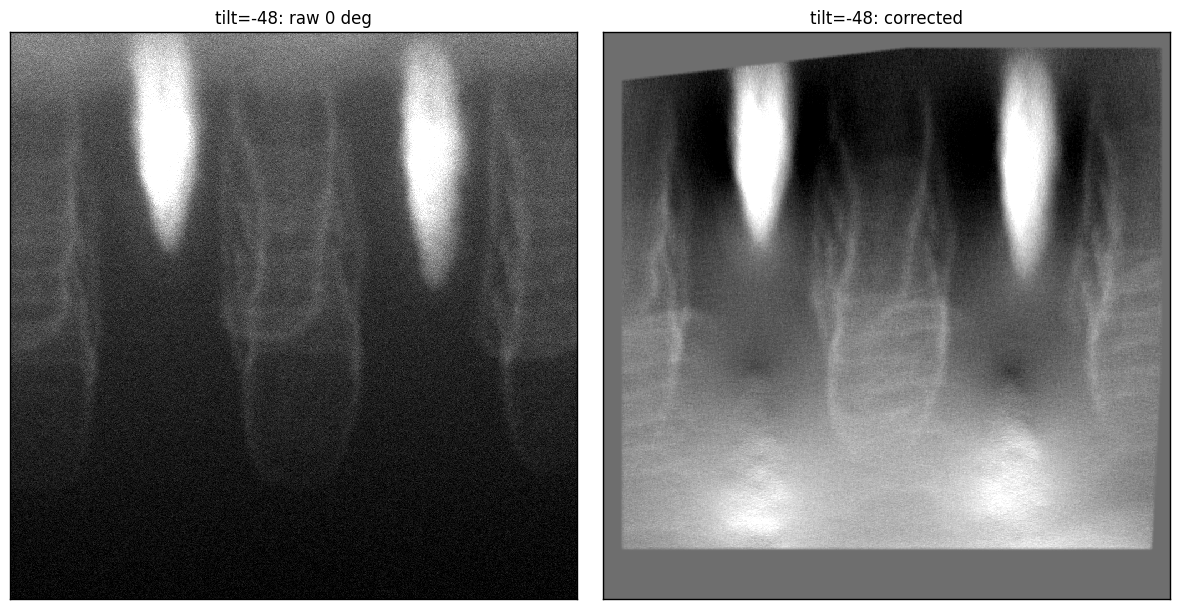

In [6]:
for tilt_idx in [0, n_tilts // 2, n_tilts - 1]:
    angle = tilt_angles[tilt_idx]
    em.visualization.show_2d(
        [images_0deg[tilt_idx], corrected_stack[tilt_idx]],
        cmap="gray",
        axsize=(6, 6),
        title=[f"tilt={angle}: raw 0 deg", f"tilt={angle}: corrected"],
    )

## Save corrected stack

In [7]:
from pathlib import Path

save_dir = Path("outputs")
save_dir.mkdir(exist_ok=True)

np.save(save_dir / "corrected_dataset1.npy", corrected_stack)
print(f"Saved corrected_dataset1.npy  shape={corrected_stack.shape}  dtype={corrected_stack.dtype}")

Saved corrected_dataset1.npy  shape=(49, 1024, 1024)  dtype=float32
